# Tutorial 06 - BME with Full Probabilistic Soft Data

**Package:** stamps_v3  
**MATLAB equivalent:** `BMEPROBALIBtutorial.m` (Part 1 - 2D spatial)
**Dataset:** Synthetic dataset generated from the Falmagne covariance model

---

## Learning objectives

1. Generate a **synthetic spatial dataset** using Cholesky simulation (`simuchol`).
2. Encode data as **Gaussian soft PDFs** and **uniform interval PDFs** using    `probaGaussian` and `probaUniform`.
3. Run **BME posterior moments** over a spatial grid using `BMEPosteriorMoments`.
4. Compute the **full posterior PDF** at selected locations using `BMEPosteriorPDF`.
5. Compute **credible intervals** (68%, 90%, 99%) using `BMEPosteriorCI`.
6. Extract **posterior quantiles** (e.g. Q10, Q50, Q90) at all estimation locations using `BMEPosteriorQtl`.

### Probabilistic vs. interval soft data

- **Interval (Tutorial 05)**: uniform PDF over $[z^{lo}, z^{up}]$.
- **Probabilistic (this tutorial)**: any non-negative function $f(z) \ge 0$   with $\int f(z)\,dz = 1$.  This is the most general BME soft data type.


In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt


from stamps.stats.simulation.simulation import simuchol
from stamps.bme.softconverter import probaGaussian, probaUniform, proba2stat
from stamps.bme.BMEprobaEstimations import (
    BMEPosteriorMoments,
    BMEPosteriorPDF,
    BMEPosteriorCI,
    BMEPosteriorQtl,
)
from stamps.graph.dataplot import (
    plot_grid_map,
    plot_exceedance_map,
    plot_iqr_map,
    plot_pdf_ribbon_transect,
)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
DATA_DIR = os.path.join(os.getcwd(), 'data')

# Load covariance model from Tutorial 03
with open(os.path.join(DATA_DIR, 'tutorial03_cov.pkl'), 'rb') as f:
    cov = pickle.load(f)
covmodel = cov['sand_covmodel']
covparam = cov['sand_covparam']

print('Covariance model:', covmodel)
for m, p in zip(covmodel, covparam):
    # covparam entries are inhomogeneous: nugget=[sill], spatial=[sill, array([range])]
    # Flatten to a 1-D float array before rounding so np.round never sees mixed types.
    p_flat = np.concatenate([np.atleast_1d(np.asarray(x, dtype=float)) for x in p])
    print(f'  {m}: {np.round(p_flat, 2)}')


Covariance model: ['nuggetC', 'sphericalC']
  nuggetC: [6.]
  sphericalC: [  69.49 2844.35]


## 1. Generate a synthetic spatial dataset

We create a controlled experiment on a 15 x 15 grid by simulating from the known covariance model.  This allows us to verify our BME estimates against the known truth.


Simulated field shape: (225,)
True mean : -0.641  (expected 0 for zero-mean)
True var  : 67.014


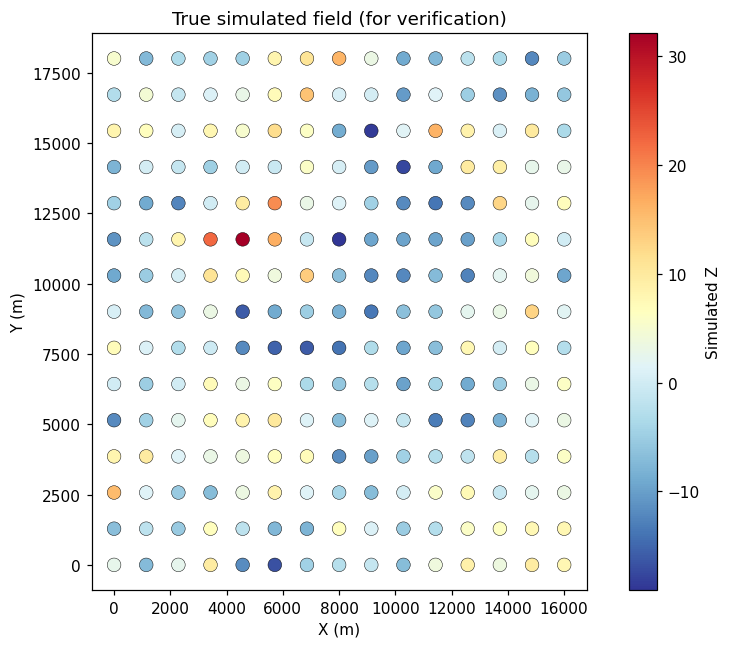

In [2]:
# Create a 15×15 regular grid matching the Falmagne study-area extent
# (≈ 16 km × 18 km).  Keeping the domain proportional to the covariance
# range (range ≈ 2844 m) ensures each estimation point has at least 4-6
# hard-data neighbours within the correlation range, giving BME a real
# spatial signal to work with (previously the 28 km × 20 km domain was
# too large — data were too sparse relative to the range).
rng = np.random.default_rng(seed=42)
nx, ny = 15, 15
x_sim = np.linspace(0, 16_000, nx)   # Falmagne width  ≈ 16 km
y_sim = np.linspace(0, 18_000, ny)   # Falmagne height ≈ 18 km
XX, YY = np.meshgrid(x_sim, y_sim)
grid_coords = np.column_stack([XX.ravel(), YY.ravel()])

# Simulate one realisation from the covariance model (zero-mean Gaussian)
zh_sim, _ = simuchol(grid_coords, covmodel, covparam, ns=1, seed=42)
zh_full   = zh_sim[:, 0]   # (n_grid,) true field

print(f'Simulated field shape: {zh_full.shape}')
print(f'True mean : {zh_full.mean():.3f}  (expected 0 for zero-mean)')
print(f'True var  : {zh_full.var():.3f}')

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(grid_coords[:, 0], grid_coords[:, 1], c=zh_full,
                cmap='RdYlBu_r', s=80, edgecolors='k', lw=0.3)
plt.colorbar(sc, ax=ax, label='Simulated Z')
ax.set_title('True simulated field (for verification)')
ax.set_aspect('equal')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
plt.tight_layout()
plt.show()


## 2. Create hard data and soft data subsets

From the simulated field we extract:

- **Hard data** (exact values): 60 locations randomly selected.  
  *(Increased from 40 → 60 so that each estimation point has ~5 hard-data  
  neighbours within the covariance range of 2844 m, giving BME a clear spatial signal.)*
- **Gaussian soft data**: 30 locations with noisy measurements  
  (mean = true value + N(0, 2²), **variance** = 4.0).
- **Estimation grid**: the remaining locations.


Hard data     : 60 locations
Gaussian soft : 30 locations  (noise std=0.2)
Estimation    : 135 locations


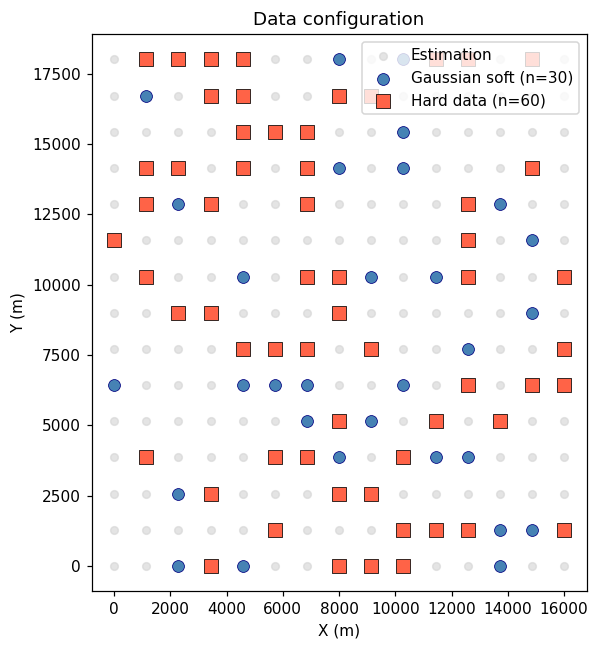

In [3]:
n_grid = len(grid_coords)
idx_all = rng.permutation(n_grid)

n_hard = 60   # increased: ~5 hard data within range per estimation point
n_soft = 30

idx_hard = idx_all[:n_hard]
idx_soft = idx_all[n_hard:n_hard + n_soft]
idx_est  = idx_all[n_hard + n_soft:]

# Hard data
ch_syn = grid_coords[idx_hard]      # (n_hard, 2)
zh_syn = zh_full[idx_hard]          # (n_hard,) exact values

# Gaussian soft data: noisy measurements
noise_std = 0.2
cs_syn    = grid_coords[idx_soft]   # (n_soft, 2)
z_soft_mean = zh_full[idx_soft] + rng.normal(0, noise_std, n_soft)  # noisy mean
z_soft_std  = noise_std * np.ones(n_soft)                            # standard deviation
z_soft_var  = noise_std**2 * np.ones(n_soft)                         # variance = std² 
# NOTE: probaGaussian(zm, zv) expects *variance* (zv), not std.
#       Passing std would silently create Gaussians that are √2 times too narrow.

# Estimation grid (remaining locations)
ck_syn  = grid_coords[idx_est]      # estimation coords
z_true  = zh_full[idx_est]          # true values for verification

print(f'Hard data     : {n_hard} locations')
print(f'Gaussian soft : {n_soft} locations  (noise std={noise_std})')
print(f'Estimation    : {len(ck_syn)} locations')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(ck_syn[:, 0],  ck_syn[:, 1],  c='lightgrey', s=25, alpha=0.6, label='Estimation')
ax.scatter(cs_syn[:, 0],  cs_syn[:, 1],  c='steelblue', s=60, marker='o',
           edgecolors='navy', lw=0.5, label=f'Gaussian soft (n={n_soft})')
ax.scatter(ch_syn[:, 0],  ch_syn[:, 1],  c='tomato',    s=80, marker='s',
           edgecolors='k',    lw=0.5, label=f'Hard data (n={n_hard})')
ax.set_title('Data configuration')
ax.set_aspect('equal')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Encode Gaussian soft PDFs with `probaGaussian`

`probaGaussian` discretises a Gaussian distribution at each soft data location into the stamps piecewise-linear PDF format:

```python
zs = probaGaussian(zmean, zvar)   # zvar = noise VARIANCE (not std!)
# Returns: [softpdftype, nl, limi, probdens]
```

> **Important:** The second argument `zv` is the **variance** $\sigma^2$, not the standard  
> deviation $\sigma$.  Passing `noise_std` instead of `noise_std**2` creates PDFs that are  
> $\sqrt{2}\approx1.41\times$ too narrow, biasing the posterior towards zero.

The resulting PDFs are centred on the noisy measurement with spread proportional to the measurement uncertainty.


In [4]:
# Check probaGaussian signature
import inspect
print(inspect.signature(probaGaussian))


(zm: numpy.ndarray, zv: numpy.ndarray) -> tuple


## Comparison: Type-2 (QMC) vs Type-10 (Analytical fast-path)

`probaGaussian` returns **`softpdftype = 2`** (piecewise-linear PDF), which forces the
BME engine to use **numerical QMC integration** over the soft-data space.

For **purely Gaussian** soft data, a smarter encoding is `softpdftype = 10` — a
native Gaussian that tells BME "this PDF is exactly Gaussian".  The engine then
uses an **analytical closed-form fast-path** (no QMC sampling required), which is
both faster and free of Monte-Carlo noise.

| Encoding | `softpdftype` | Integration | Speed | Noise |
|---|---|---|---|---|
| `probaGaussian(zm, zv)` | 2 (piecewise-linear) | QMC | slow | MC noise |
| native Gaussian list | 10 | Analytical | fast | none |

> Both encodings represent the **same Gaussian PDF**.  Any difference in posterior
> mean/variance is purely numerical noise from QMC sampling.  The Type-10 result
> is the exact analytical answer and can serve as a ground-truth reference.

In [5]:
import time
from stamps.bme.softconverter import probaGaussian

# ── Encode type-2 (piecewise-linear) Gaussian soft data ─────────────────────
# NOTE: probaGaussian(zm, zv) expects *variance* (zv), not std.
# z_soft_var = noise_std**2 is defined in the 'subsets' cell above.
zs_gauss = probaGaussian(z_soft_mean, z_soft_var)
print(f'Type-2  encoding: softpdftype={zs_gauss[0]}, '
      f'nl shape={zs_gauss[1].shape}, limi shape={zs_gauss[2].shape}')

# ── Build type-10 (native Gaussian) soft data ───────────────────────────────
# Format: a list of ns tuples  (softpdftype=10, mean_i, variance_i)
# When BMEPosteriorMoments sees all type-10 soft data + Gaussian prior it
# detects the all-Gaussian case and bypasses QMC entirely.
zs_gauss_t10 = [
    (10, float(z_soft_mean[i]), float(z_soft_var[i]))
    for i in range(n_soft)
]
print(f'Type-10 encoding: {len(zs_gauss_t10)} tuples (10, mean, var)')
for t in zs_gauss_t10[:3]:
    print(f'  {t}')

nhmax_c, nsmax_c, dmax_c = 10, 8, 12_000.0

# ── Type-2: piecewise-linear → QMC integration ──────────────────────────────
print('\n=== Type-2  (piecewise-linear, QMC) ===')
t0 = time.perf_counter()
result_t2 = BMEPosteriorMoments(
    ck_syn, ch=ch_syn, cs=cs_syn,
    zh=zh_syn.reshape(-1, 1), zs=zs_gauss,
    covmodel=covmodel, covparam=covparam,
    order=np.nan, nhmax=nhmax_c, nsmax=nsmax_c,
    dmax=np.array([[dmax_c]]),
)
t_t2 = time.perf_counter() - t0
bme_mean_t2 = result_t2[:, 0];  bme_var_t2 = result_t2[:, 1]
valid_t2 = ~np.isnan(bme_mean_t2)
rmse_t2  = np.sqrt(np.mean((bme_mean_t2[valid_t2] - z_true[valid_t2])**2))
print(f'  RMSE vs truth : {rmse_t2:.4f}  |  time: {t_t2:.2f}s')

# ── Type-10: native Gaussian → analytical fast-path ─────────────────────────
print('\n=== Type-10 (native Gaussian, analytical) ===')
t0 = time.perf_counter()
result_t10 = BMEPosteriorMoments(
    ck_syn, ch=ch_syn, cs=cs_syn,
    zh=zh_syn.reshape(-1, 1), zs=zs_gauss_t10,
    covmodel=covmodel, covparam=covparam,
    order=np.nan, nhmax=nhmax_c, nsmax=nsmax_c,
    dmax=np.array([[dmax_c]]),
)
t_t10 = time.perf_counter() - t0
bme_mean_t10 = result_t10[:, 0];  bme_var_t10 = result_t10[:, 1]
valid_t10 = ~np.isnan(bme_mean_t10)
rmse_t10  = np.sqrt(np.mean((bme_mean_t10[valid_t10] - z_true[valid_t10])**2))
print(f'  RMSE vs truth : {rmse_t10:.4f}  |  time: {t_t10:.2f}s')

# ── Summary table ────────────────────────────────────────────────────────────
print('\n' + '─'*55)
print(f"{'':>20} {'Type-2 QMC':>16} {'Type-10 Anal.':>16}")
print('─'*55)
print(f"{'RMSE vs truth':>20} {rmse_t2:>16.4f} {rmse_t10:>16.4f}")
print(f"{'Mean variance':>20} {np.nanmean(bme_var_t2):>16.4f} {np.nanmean(bme_var_t10):>16.4f}")
print(f"{'Wall-time (s)':>20} {t_t2:>16.2f} {t_t10:>16.2f}")
speed = t_t2 / max(t_t10, 1e-3)
print(f"{'Speed-up':>20} {'—':>16} {speed:>14.1f}×")
print('─'*55)
print(f'RMSE difference (QMC − Analytical): {rmse_t2 - rmse_t10:+.4f}')
print('(should be small — any gap is pure QMC noise)')

Type-2  encoding: softpdftype=2, nl shape=(30, 1), limi shape=(30, 13)
Type-10 encoding: 30 tuples (10, mean, var)
  (10, 12.886411907828226, 0.04000000000000001)
  (10, 12.891682251453148, 0.04000000000000001)
  (10, -11.703305902844287, 0.04000000000000001)

=== Type-2  (piecewise-linear, QMC) ===
preparing...done
[STARBME] BME estimation: nk=135, nh=60, ns=30, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


135 / 135
[STARBME] BME estimation completed in 1.2s (0.009s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.002333, max=0.0126; rel_err  median=0.11%, max=2.53% (135 of 135 points had QMC error info)
  RMSE vs truth : 7.1299  |  time: 1.22s

=== Type-10 (native Gaussian, analytical) ===
preparing...done
[STARBME] BME estimation: nk=135, nh=60, ns=30, soft types={10}, approx_gaussian=False
135 / 135
[STARBME] BME estimation completed in 0.1s (0.001s per point)
  RMSE vs truth : 7.1299  |  time: 0.09s

───────────────────────────────────────────────────────
                           Type-2 QMC    Type-10 Anal.
───────────────────────────────────────────────────────
       RMSE vs truth           7.1299           7.1299
       Mean variance          59.6423          59.6421
       Wall-time (s)             1.22             0.09
            Speed-up                —           13.3×
───────────────────────────────────────────────────────
RMSE difference (QMC − Analytical): +

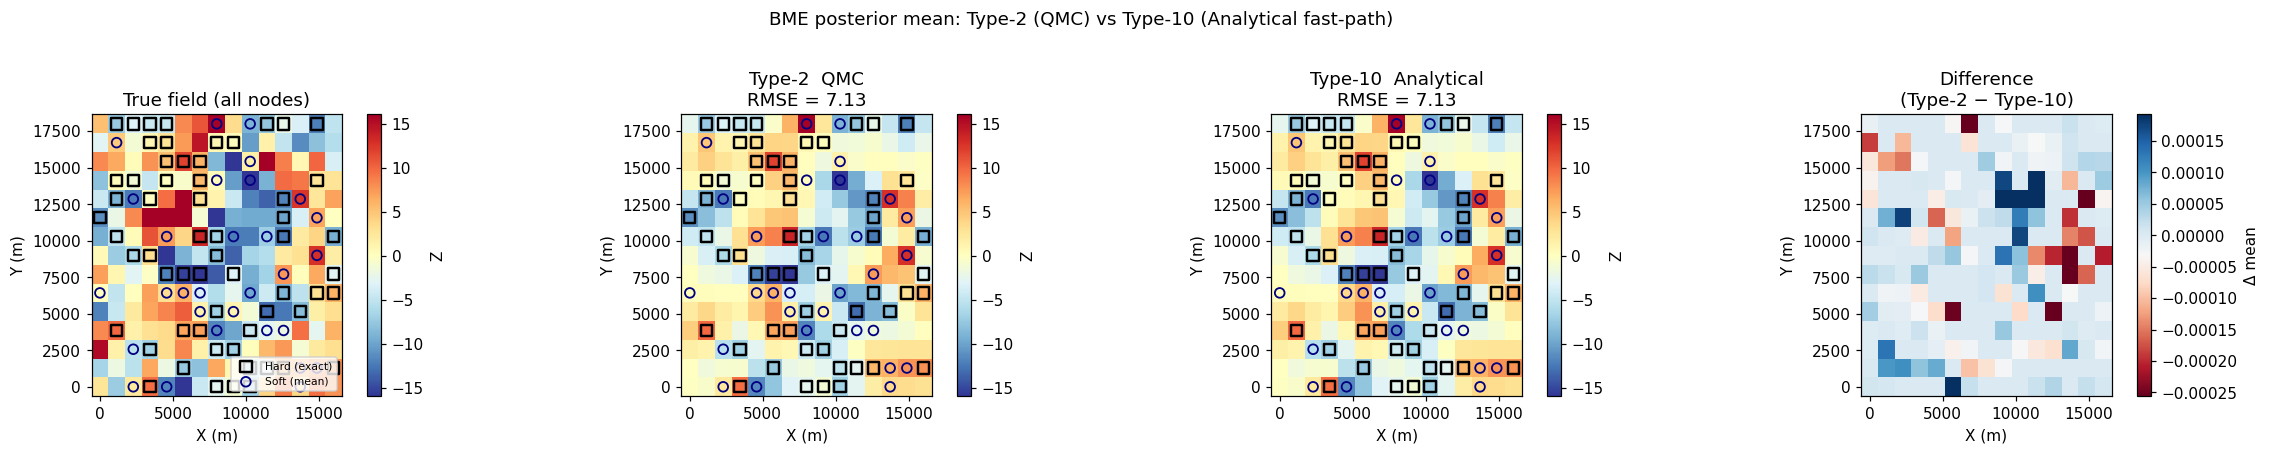


Computing posterior PDFs at location 67: [ 8000.         12857.14285714]
preparing...done
[STARBME] BME estimation: nk=1, nh=60, ns=30, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.
1 / 1
[STARBME] BME estimation completed in 0.0s (0.013s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.0003306, max=0.0003306; rel_err  median=0.04%, max=0.04% (1 of 1 points had QMC error info)
preparing...done
[STARBME] BME estimation: nk=1, nh=60, ns=30, soft types={10}, approx_gaussian=False
1 / 1
[STARBME] BME estimation completed in 0.0s (0.001s per point)


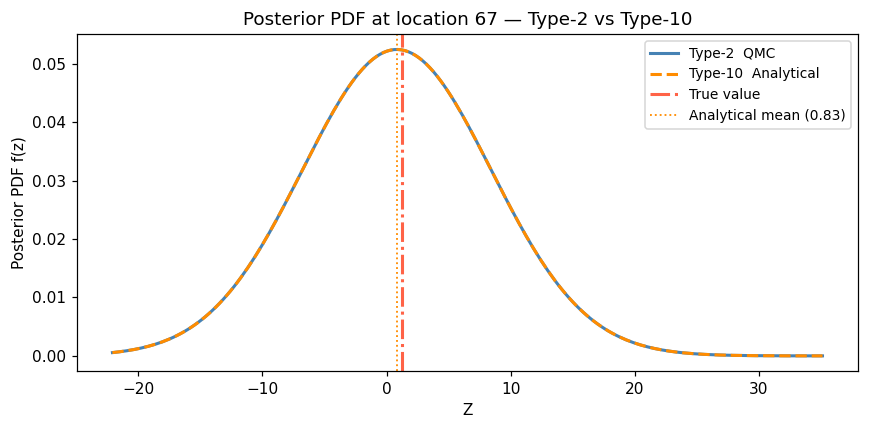

True value at loc 67     : 1.249
Type-2  QMC  posterior mean      : 0.829
Type-10 Anal. posterior mean     : 0.829


In [6]:
# ── Side-by-side maps: True field | Type-2 QMC | Type-10 Analytical | Diff ──
# Fill all nodes: estimation nodes → BME result,
#                 hard data nodes  → exact observation,
#                 soft data nodes  → soft-data mean (E[PDF])
Z_true_disp = zh_full.copy()    # known everywhere

Z_t2_disp = np.full(n_grid, np.nan)
Z_t2_disp[idx_est]  = bme_mean_t2
Z_t2_disp[idx_hard] = zh_syn
Z_t2_disp[idx_soft] = z_soft_mean

Z_t10_disp = np.full(n_grid, np.nan)
Z_t10_disp[idx_est]  = bme_mean_t10
Z_t10_disp[idx_hard] = zh_syn
Z_t10_disp[idx_soft] = z_soft_mean

Z_diff_disp = np.full(n_grid, np.nan)
Z_diff_disp[idx_est]  = bme_mean_t2 - bme_mean_t10
Z_diff_disp[idx_hard] = 0.0   # identical inputs → zero difference
Z_diff_disp[idx_soft] = 0.0

vz_lo = np.nanpercentile(zh_full, 2)
vz_hi = np.nanpercentile(zh_full, 98)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

plot_grid_map(axes[0], grid_coords, Z_true_disp,
              title='True field (all nodes)', vmin=vz_lo, vmax=vz_hi,
              cmap='RdYlBu_r', colorbar_label='Z', xlabel='X (m)', ylabel='Y (m)')
plot_grid_map(axes[1], grid_coords, Z_t2_disp,
              title=f'Type-2  QMC\nRMSE = {rmse_t2:.2f}', vmin=vz_lo, vmax=vz_hi,
              cmap='RdYlBu_r', colorbar_label='Z', xlabel='X (m)', ylabel='Y (m)')
plot_grid_map(axes[2], grid_coords, Z_t10_disp,
              title=f'Type-10  Analytical\nRMSE = {rmse_t10:.2f}', vmin=vz_lo, vmax=vz_hi,
              cmap='RdYlBu_r', colorbar_label='Z', xlabel='X (m)', ylabel='Y (m)')
plot_grid_map(axes[3], grid_coords, Z_diff_disp,
              title='Difference\n(Type-2 − Type-10)',
              cmap='RdBu', colorbar_label='Δ mean', xlabel='X (m)', ylabel='Y (m)')

# Mark data types with outlines only — fill colour comes from the colorscale
for ax in axes[:3]:
    ax.scatter(ch_syn[:, 0], ch_syn[:, 1],
               facecolors='none', edgecolors='k', s=55, marker='s',
               lw=1.6, zorder=4, label='Hard (exact)')
    ax.scatter(cs_syn[:, 0], cs_syn[:, 1],
               facecolors='none', edgecolors='navy', s=40,
               lw=1.2, zorder=3, label='Soft (mean)')
axes[0].legend(fontsize=7, loc='lower right')

plt.suptitle(
    'BME posterior mean: Type-2 (QMC) vs Type-10 (Analytical fast-path)',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── PDF comparison at the central estimation point ──────────────────────────
from scipy.stats import norm as scipy_norm

i_sel_cmp = len(ck_syn) // 2
ck_cmp    = ck_syn[[i_sel_cmp], :]

z_lo_cmp = zh_full.min() - 3
z_hi_cmp = zh_full.max() + 3
z_grid_cmp = np.linspace(z_lo_cmp, z_hi_cmp, 200)

print(f'\nComputing posterior PDFs at location {i_sel_cmp}: {ck_cmp[0]}')

# Type-2
_, pdf_t2_vals, _ = BMEPosteriorPDF(
    ck_cmp,
    ch=ch_syn, cs=cs_syn,
    zh=zh_syn.reshape(-1, 1), zs=zs_gauss,
    covmodel=covmodel, covparam=covparam,
    order=np.nan, nhmax=nhmax_c, nsmax=nsmax_c,
    dmax=np.array([[dmax_c]]),
    z_grid=z_grid_cmp,
)
pdf_t2_cmp = np.asarray(pdf_t2_vals).ravel()

# Type-10
_, pdf_t10_vals, _ = BMEPosteriorPDF(
    ck_cmp,
    ch=ch_syn, cs=cs_syn,
    zh=zh_syn.reshape(-1, 1), zs=zs_gauss_t10,
    covmodel=covmodel, covparam=covparam,
    order=np.nan, nhmax=nhmax_c, nsmax=nsmax_c,
    dmax=np.array([[dmax_c]]),
    z_grid=z_grid_cmp,
)
pdf_t10_cmp = np.asarray(pdf_t10_vals).ravel()

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(z_grid_cmp, pdf_t2_cmp,  'steelblue', lw=2,   label='Type-2  QMC')
ax2.plot(z_grid_cmp, pdf_t10_cmp, 'darkorange', lw=2, ls='--',
         label='Type-10  Analytical')
ax2.axvline(z_true[i_sel_cmp], color='tomato', lw=2, ls='-.', label='True value')
ax2.axvline(bme_mean_t10[i_sel_cmp], color='darkorange', lw=1.2, ls=':',
            label=f'Analytical mean ({bme_mean_t10[i_sel_cmp]:.2f})')
ax2.set_xlabel('Z');  ax2.set_ylabel('Posterior PDF f(z)')
ax2.set_title(f'Posterior PDF at location {i_sel_cmp} — Type-2 vs Type-10')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'True value at loc {i_sel_cmp}     : {z_true[i_sel_cmp]:.3f}')
print(f'Type-2  QMC  posterior mean      : {bme_mean_t2[i_sel_cmp]:.3f}')
print(f'Type-10 Anal. posterior mean     : {bme_mean_t10[i_sel_cmp]:.3f}')

softpdftype : 2
nl shape    : (30, 1)  (max nl = 13)
limi shape  : (30, 13)
probdens shape: (30, 13)

Mean of soft means : -0.109
Mean of soft vars  : 0.043  (expected ~0.0)


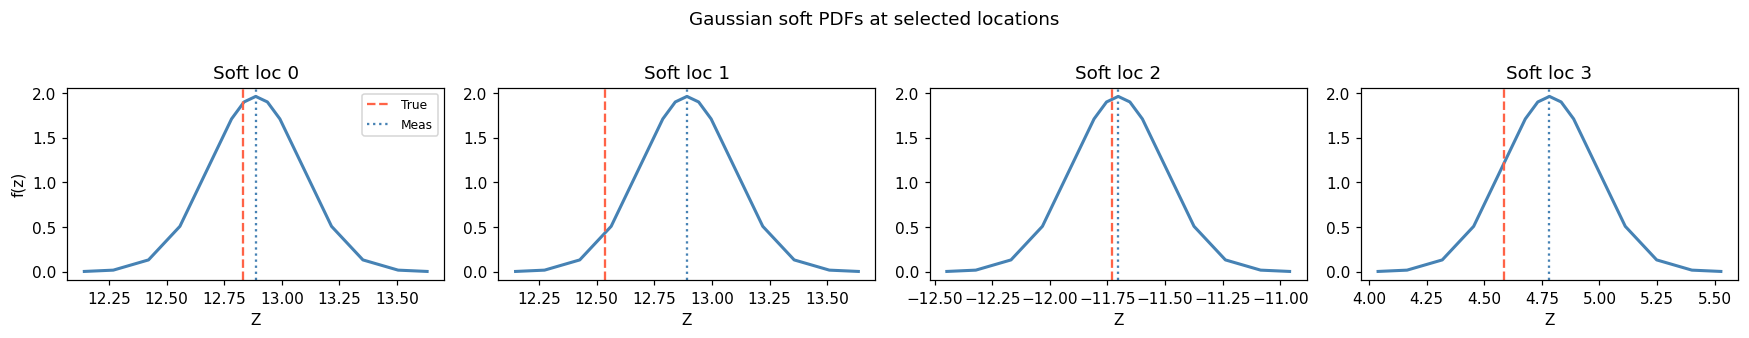

In [7]:
# zs_gauss was already defined and used in the comparison cell above.
# We unpack it here for visualisation purposes only.
soft_type, nl_g, limi_g, pd_g = zs_gauss

print(f'softpdftype : {soft_type}')
print(f'nl shape    : {nl_g.shape}  (max nl = {nl_g.max()})')
print(f'limi shape  : {limi_g.shape}')
print(f'probdens shape: {pd_g.shape}')

# Compute soft data statistics
s_mean, s_var = proba2stat(soft_type, nl_g, limi_g, pd_g)
print(f'\nMean of soft means : {s_mean.mean():.3f}')
print(f'Mean of soft vars  : {s_var.mean():.3f}  (expected ~{noise_std**2:.1f})')

# Visualise PDFs at a few locations
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, ax in enumerate(axes):
    n_i = int(nl_g[i, 0])
    x_i = limi_g[i, :n_i]
    y_i = pd_g[i, :n_i]
    ax.plot(x_i, y_i, 'steelblue', lw=2)
    ax.axvline(zh_full[idx_soft[i]], color='tomato', ls='--', lw=1.5, label='True')
    ax.axvline(z_soft_mean[i], color='steelblue', ls=':', lw=1.5, label='Meas')
    ax.set_title(f'Soft loc {i}')
    ax.set_xlabel('Z')
    if i == 0:
        ax.set_ylabel('f(z)')
        ax.legend(fontsize=8)
plt.suptitle('Gaussian soft PDFs at selected locations', y=1.01)
plt.tight_layout()
plt.show()


## 4. BME posterior moments

Combine hard and Gaussian-soft data to compute BME posterior mean and variance at all estimation grid nodes.


In [8]:
# Reuse Type-2 QMC results already computed in the comparison section above.
# This avoids running BMEPosteriorMoments a second time.
nhmax = nhmax_c;  nsmax = nsmax_c;  dmax = dmax_c

bme_mean = bme_mean_t2   # (nk,) posterior mean  – Type-2 QMC
bme_var  = bme_var_t2    # (nk,) posterior variance

valid = ~np.isnan(bme_mean)
rmse  = np.sqrt(np.mean((bme_mean[valid] - z_true[valid])**2))
print(f'BME (Type-2 QMC)   RMSE vs truth : {rmse:.4f}')
print(f'BME (Type-10 Anal) RMSE vs truth : {rmse_t10:.4f}')
print(f'Mean BME variance                : {np.nanmean(bme_var):.4f}')
print(f'Estimated nodes                  : {valid.sum()} / {len(ck_syn)}')


BME (Type-2 QMC)   RMSE vs truth : 7.1299
BME (Type-10 Anal) RMSE vs truth : 7.1299
Mean BME variance                : 59.6423
Estimated nodes                  : 135 / 135


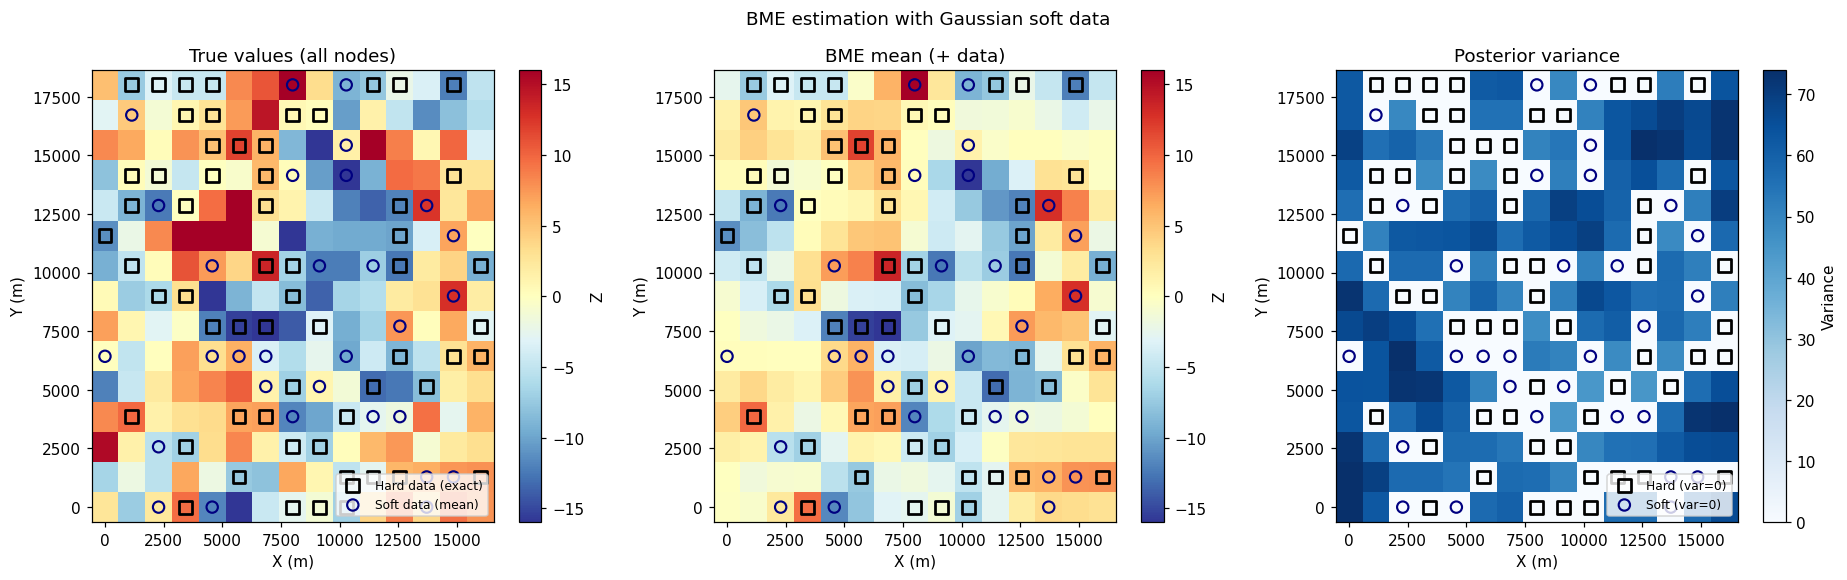

In [9]:
# ── Reconstruct full grid for display ───────────────────────────────────────
# True field: fill ALL 225 nodes with the known simulated value.
z_display_true = zh_full.copy()   # no NaN — every node has a true value

# BME mean:
#   • estimation nodes  → BME posterior mean
#   • hard data nodes   → exact observation (posterior = data; no uncertainty)
#   • soft data nodes   → soft-data mean (best point estimate of the measurement)
z_display_mean = np.full(n_grid, np.nan)
z_display_mean[idx_est]  = bme_mean
z_display_mean[idx_hard] = zh_syn
z_display_mean[idx_soft] = z_soft_mean   # E[soft PDF] ≈ noisy measurement mean

# BME variance:
#   • estimation nodes → BME posterior variance
#   • hard data nodes  → 0  (known exactly)
#   • soft data nodes  → measurement variance (noise_std²)
z_display_var = np.full(n_grid, np.nan)
z_display_var[idx_est]  = bme_var
z_display_var[idx_hard] = 0.0
z_display_var[idx_soft] = z_soft_var

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

vz_lo = np.nanpercentile(zh_full, 2)
vz_hi = np.nanpercentile(zh_full, 98)

plot_grid_map(axes[0], grid_coords, z_display_true,
              title='True values (all nodes)', vmin=vz_lo, vmax=vz_hi,
              cmap='RdYlBu_r', colorbar_label='Z', xlabel='X (m)', ylabel='Y (m)')
plot_grid_map(axes[1], grid_coords, z_display_mean,
              title='BME mean (+ data)', vmin=vz_lo, vmax=vz_hi,
              cmap='RdYlBu_r', colorbar_label='Z', xlabel='X (m)', ylabel='Y (m)')
plot_grid_map(axes[2], grid_coords, z_display_var,
              title='Posterior variance', cmap='Blues',
              colorbar_label='Variance', xlabel='X (m)', ylabel='Y (m)')

# Mark data types with outlines only — fill colour comes from the colorscale
for ax in axes[:2]:
    ax.scatter(ch_syn[:, 0], ch_syn[:, 1],
               facecolors='none', edgecolors='k', s=70, marker='s',
               lw=1.8, zorder=4, label='Hard data (exact)')
    ax.scatter(cs_syn[:, 0], cs_syn[:, 1],
               facecolors='none', edgecolors='navy', s=55,
               lw=1.4, zorder=3, label='Soft data (mean)')
axes[0].legend(fontsize=8, loc='lower right')

# Mark data types on variance panel too
axes[2].scatter(ch_syn[:, 0], ch_syn[:, 1],
                facecolors='none', edgecolors='k', s=70, marker='s',
                lw=1.8, zorder=4, label='Hard (var=0)')
axes[2].scatter(cs_syn[:, 0], cs_syn[:, 1],
                facecolors='none', edgecolors='navy', s=55,
                lw=1.4, zorder=3, label=f'Soft (var={noise_std**2:.0f})')
axes[2].legend(fontsize=8, loc='lower right')

plt.suptitle('BME estimation with Gaussian soft data', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 5. Posterior PDF at a single location

`BMEPosteriorPDF` computes the full posterior PDF $f_k(z)$ at each estimation location. The z evaluation range is determined automatically from the data and model (Gaussian-approximated posterior moments), so no z-grid needs to be supplied. An explicit `z_grid` can be passed when a fixed range is preferred. This is the full Bayesian result — the posterior moments computed above are derived from it.


In [10]:
# Choose a single estimation location near the centre
i_sel = len(ck_syn) // 2
ck_single = ck_syn[[i_sel], :]   # shape (1, 2)

# Z-grid for PDF evaluation
z_min = zh_full.min() - 2
z_max = zh_full.max() + 2
z_grid = np.linspace(z_min, z_max, 150)

print(f'Computing posterior PDF at location {ck_single[0]}...')
# BMEPosteriorPDF returns (z_out, pdf_values, info)
z_out, pdf_values, info_pdf = BMEPosteriorPDF(
    ck_single,
    ch=ch_syn, cs=cs_syn,
    zh=zh_syn.reshape(-1, 1),
    zs=zs_gauss,
    covmodel=covmodel, covparam=covparam,
    order=np.nan,
    nhmax=nhmax, nsmax=nsmax,
    dmax=np.array([[dmax]]),
    z_grid=z_grid,
)

# z_out: shared z-grid (same as z_grid when z_grid was supplied)
# pdf_values: (nk, nz) array of PDF values; ravel gives (nz,) for nk=1
z_grid = np.asarray(z_out).ravel()
pdf_at_loc = np.asarray(pdf_values).ravel()
print(f'PDF shape: {pdf_at_loc.shape}, integral ~ {np.trapezoid(pdf_at_loc, z_grid):.3f}')


Computing posterior PDF at location [ 8000.         12857.14285714]...
preparing...done
[STARBME] BME estimation: nk=1, nh=60, ns=30, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.
1 / 1
[STARBME] BME estimation completed in 0.0s (0.016s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.0003306, max=0.0003306; rel_err  median=0.04%, max=0.04% (1 of 1 points had QMC error info)
PDF shape: (150,), integral ~ 0.998


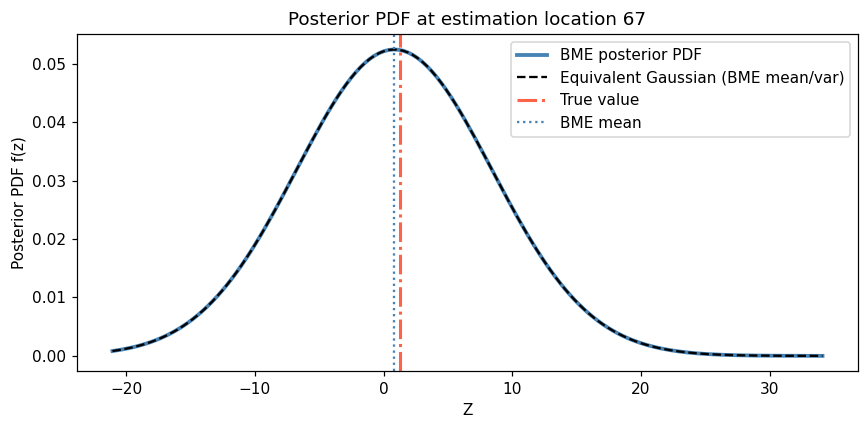

In [11]:
from scipy.stats import norm as scipy_norm

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z_grid, pdf_at_loc, 'steelblue', lw=2.5, label='BME posterior PDF')

# Overlay Gaussian with BME mean/variance for comparison
bme_m_i = bme_mean[i_sel]
bme_v_i = bme_var[i_sel]
if not np.isnan(bme_m_i) and bme_v_i > 0:
    y_gauss = scipy_norm.pdf(z_grid, loc=bme_m_i, scale=np.sqrt(bme_v_i))
    ax.plot(z_grid, y_gauss, 'k--', lw=1.5, label='Equivalent Gaussian (BME mean/var)')

ax.axvline(z_true[i_sel], color='tomato',   lw=2, ls='-.',  label='True value')
ax.axvline(bme_m_i,       color='steelblue',lw=1.5, ls=':',label='BME mean')
ax.set_xlabel('Z')
ax.set_ylabel('Posterior PDF f(z)')
ax.set_title(f'Posterior PDF at estimation location {i_sel}')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Credible intervals with `BMEPosteriorCI`

`BMEPosteriorCI` computes the Bayesian credible interval at each estimation location.  A 95% credible interval $[L, U]$ means:

$$\int_L^U f_k(z)\,dz = 0.95$$

This is the Bayesian analogue of a confidence interval.


In [12]:
# Compute credible intervals at all estimation locations
ci_levels = [0.68, 0.90, 0.99]

print('Running BMEPosteriorCI for credible intervals...')
# BMEPosteriorCI returns a 6-tuple:
#   zlCI   : (nk, nCI)  lower CI bounds
#   zuCI   : (nk, nCI)  upper CI bounds
#   pdfCI  : (nk, nCI)  PDF value at lower bound
#   PCI    : (nCI,)     CI probability levels (sorted)
#   z_grids_ci  : list of nk z-grids (one per point)
#   pdf_grids_ci: list of nk normalised PDF arrays
zlCI, zuCI, pdfCI, PCI, z_grids_ci, pdf_grids_ci = BMEPosteriorCI(
    ck_syn,
    ch=ch_syn, cs=cs_syn,
    zh=zh_syn.reshape(-1, 1),
    zs=zs_gauss,
    covmodel=covmodel, covparam=covparam,
    order=np.nan,
    nhmax=nhmax, nsmax=nsmax,
    dmax=np.array([[dmax]]),
    ci_probs=ci_levels,
)

print(f'zlCI shape: {zlCI.shape}, zuCI shape: {zuCI.shape}')
print(f'CI levels used: {PCI}')


Running BMEPosteriorCI for credible intervals...
preparing...done
[STARBME] BME estimation: nk=135, nh=60, ns=30, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


135 / 135
[STARBME] BME estimation completed in 1.2s (0.009s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.002333, max=0.0126; rel_err  median=0.11%, max=2.53% (135 of 135 points had QMC error info)
zlCI shape: (135, 3), zuCI shape: (135, 3)
CI levels used: [0.68 0.9  0.99]


In [13]:
# Inspect the CI arrays
# zlCI[i, j] = lower bound for estimation point i, CI level j
# zuCI[i, j] = upper bound for estimation point i, CI level j
print('Lower bounds (zlCI) shape:', zlCI.shape)   # (nk, nCI)
print('Upper bounds (zuCI) shape:', zuCI.shape)   # (nk, nCI)
print('PDF at bounds (pdfCI) shape:', pdfCI.shape)
print('CI probability levels (PCI):', PCI)

# Show interval widths at location i_sel
print(f'\nAt location {i_sel}:')
for j, p in enumerate(PCI):
    print(f'  {int(100*p):>3}% CI: [{zlCI[i_sel, j]:.3f}, {zuCI[i_sel, j]:.3f}]')


Lower bounds (zlCI) shape: (135, 3)
Upper bounds (zuCI) shape: (135, 3)
PDF at bounds (pdfCI) shape: (135, 3)
CI probability levels (PCI): [0.68 0.9  0.99]

At location 67:
   68% CI: [-6.733, 8.391]
   90% CI: [-11.678, 13.337]
   99% CI: [-18.758, 20.416]


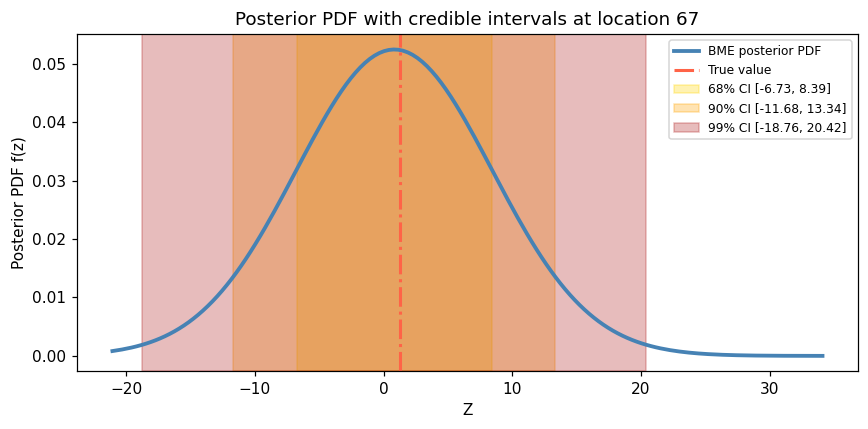

In [14]:
# Plot the posterior PDF with credible interval shading at the selected location
i_sel2 = i_sel   # same location used for PDF plot above

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z_grid, pdf_at_loc, 'steelblue', lw=2.5, label='BME posterior PDF')
ax.axvline(z_true[i_sel], color='tomato', lw=2, ls='-.', label='True value')

colors_ci = ['gold', 'orange', 'firebrick']
# zlCI[i, j] / zuCI[i, j]: lower/upper bounds for point i, CI level j
for j, (alpha_ci, col) in enumerate(zip(PCI, colors_ci)):
    lo_i = float(zlCI[i_sel2, j])
    hi_i = float(zuCI[i_sel2, j])
    if not (np.isnan(lo_i) or np.isnan(hi_i)):
        ax.axvspan(lo_i, hi_i, alpha=0.3, color=col,
                   label=f'{int(100*alpha_ci)}% CI [{lo_i:.2f}, {hi_i:.2f}]')

ax.set_xlabel('Z')
ax.set_ylabel('Posterior PDF f(z)')
ax.set_title(f'Posterior PDF with credible intervals at location {i_sel}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 7. Posterior quantiles with `BMEPosteriorQtl`

`BMEPosteriorQtl` returns the z-value at each requested quantile level of the posterior distribution at every estimation location.  It is a clean single-output alternative to `BMEPosteriorCI`:

- **Input**: arbitrary quantile levels, e.g. `[0.1, 0.3, 0.5, 0.7, 0.9]`
- **Output**: array of shape `(nk, nq)` — one row per estimation location, one column per quantile

The 0.5 quantile (median) is a robust alternative to the posterior mean, and the 0.1/0.9 quantiles give an 80 % predictive interval without requiring the symmetric equal-tail assumption of `BMEPosteriorCI`.

preparing...done
[STARBME] BME estimation: nk=135, nh=60, ns=30, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


135 / 135
[STARBME] BME estimation completed in 1.2s (0.009s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.002333, max=0.0126; rel_err  median=0.11%, max=2.53% (135 of 135 points had QMC error info)
zq shape: (135, 5)  (nk=135, nq=5)
Quantile levels: [0.1, 0.3, 0.5, 0.7, 0.9]
First 5 rows:
[[-10.593  -4.646  -0.526   3.593   9.541]
 [ -7.293  -1.848   1.923   5.694  11.139]
 [-11.315  -4.746  -0.196   4.353  10.922]
 [ -9.146  -3.456   0.485   4.426  10.116]
 [-12.312  -5.99   -1.611   2.767   9.089]]


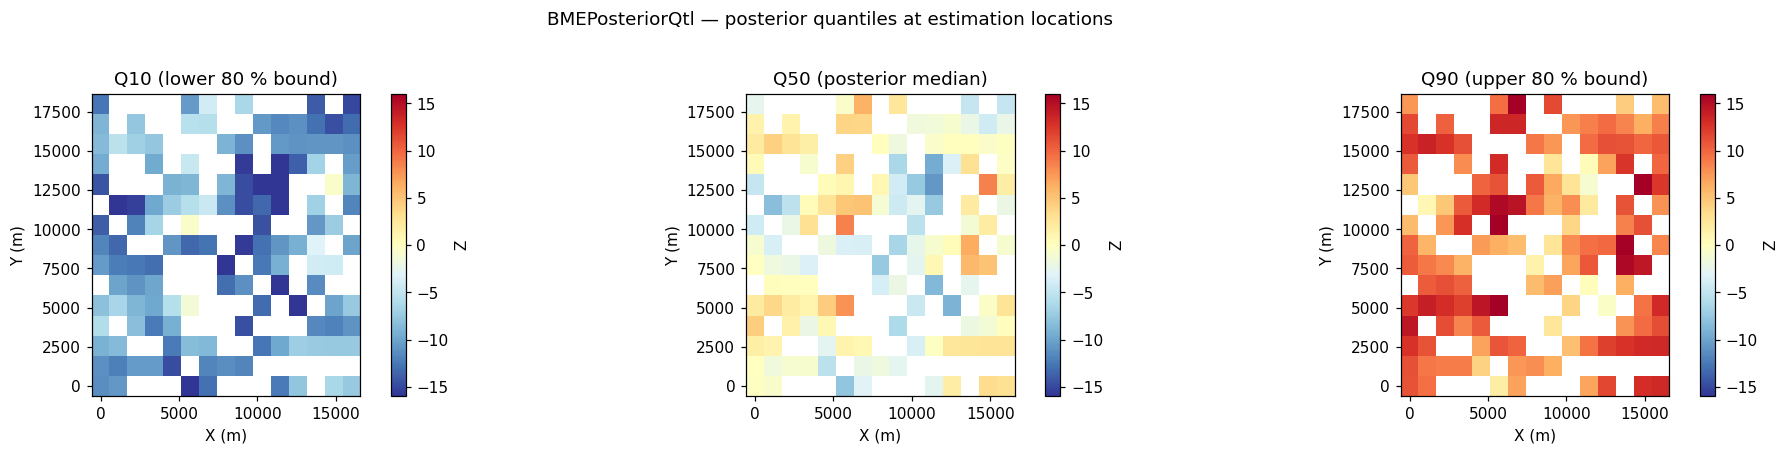


Median vs mean comparison at 135 estimation points:
  Max |median − mean| : 0.0000
  Mean |median − mean|: 0.0000
  (small values confirm near-Gaussian posterior shape)


In [15]:
# ── Compute posterior quantiles at all estimation locations ──────────────────
qtl_levels = [0.1, 0.3, 0.5, 0.7, 0.9]

zq = BMEPosteriorQtl(
    ck_syn,
    ch=ch_syn, cs=cs_syn,
    zh=zh_syn.reshape(-1, 1), zs=zs_gauss,
    covmodel=covmodel, covparam=covparam,
    order=np.nan, nhmax=nhmax, nsmax=nsmax,
    dmax=np.array([[dmax]]),
    quantiles=qtl_levels,
)
# zq shape: (nk, nq)
print(f'zq shape: {zq.shape}  (nk={len(ck_syn)}, nq={len(qtl_levels)})')
print(f'Quantile levels: {qtl_levels}')
print(f'First 5 rows:\n{zq[:5].round(3)}')

# ── Plot: median and 80 % predictive band at all estimation nodes ────────────
idx_med  = qtl_levels.index(0.5)
idx_lo   = qtl_levels.index(0.1)
idx_hi   = qtl_levels.index(0.9)

Z_med  = np.full(n_grid, np.nan)
Z_lo   = np.full(n_grid, np.nan)
Z_hi   = np.full(n_grid, np.nan)
Z_med[idx_est]  = zq[:, idx_med]
Z_lo[idx_est]   = zq[:, idx_lo]
Z_hi[idx_est]   = zq[:, idx_hi]

vz_lo = np.nanpercentile(zh_full, 2)
vz_hi = np.nanpercentile(zh_full, 98)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_grid_map(axes[0], grid_coords, Z_lo,
              title='Q10 (lower 80 % bound)', vmin=vz_lo, vmax=vz_hi,
              cmap='RdYlBu_r', colorbar_label='Z', xlabel='X (m)', ylabel='Y (m)')
plot_grid_map(axes[1], grid_coords, Z_med,
              title='Q50 (posterior median)', vmin=vz_lo, vmax=vz_hi,
              cmap='RdYlBu_r', colorbar_label='Z', xlabel='X (m)', ylabel='Y (m)')
plot_grid_map(axes[2], grid_coords, Z_hi,
              title='Q90 (upper 80 % bound)', vmin=vz_lo, vmax=vz_hi,
              cmap='RdYlBu_r', colorbar_label='Z', xlabel='X (m)', ylabel='Y (m)')
plt.suptitle('BMEPosteriorQtl — posterior quantiles at estimation locations',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Compare median vs mean ───────────────────────────────────────────────────
med_est = zq[:, idx_med]
mean_est = bme_mean
valid = ~np.isnan(med_est) & ~np.isnan(mean_est)
print(f'\nMedian vs mean comparison at {valid.sum()} estimation points:')
print(f'  Max |median − mean| : {np.abs(med_est[valid] - mean_est[valid]).max():.4f}')
print(f'  Mean |median − mean|: {np.abs(med_est[valid] - mean_est[valid]).mean():.4f}')
print(f'  (small values confirm near-Gaussian posterior shape)')

### Spatial PDF and quantile visualisations

The three helper functions `plot_exceedance_map`, `plot_iqr_map`, and
`plot_pdf_ribbon_transect` (from `stamps.graph`) turn the full posterior
PDF and quantile outputs into publication-ready maps and transect ribbons.

- **Exceedance-probability map** — $P(Z > t)$ at every grid node.
- **Inter-quantile range (IQR) map** — width of the 80 % predictive band
  ($Q_{90} - Q_{10}$) as a spatial uncertainty indicator.
- **PDF ribbon transect** — quantile-band envelope along a one-dimensional
  slice through the grid.

preparing...done
[STARBME] BME estimation: nk=135, nh=60, ns=30, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


135 / 135
[STARBME] BME estimation completed in 1.2s (0.009s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.002333, max=0.0126; rel_err  median=0.11%, max=2.53% (135 of 135 points had QMC error info)
Computed posterior PDFs at 135 estimation points


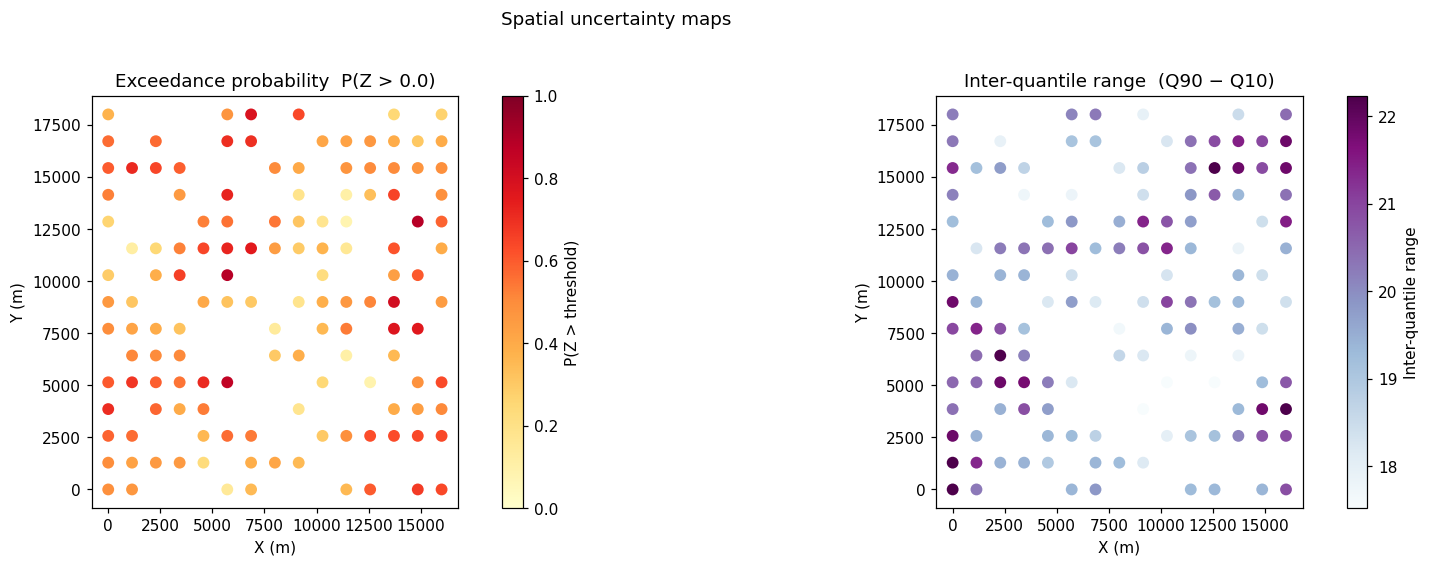

In [16]:
# ── Compute full posterior PDFs at all estimation locations (auto z-grid) ─────
z_out_grid, pdf_out_grid, _ = BMEPosteriorPDF(
    ck_syn,
    ch=ch_syn, cs=cs_syn,
    zh=zh_syn.reshape(-1, 1), zs=zs_gauss,
    covmodel=covmodel, covparam=covparam,
    order=np.nan, nhmax=nhmax, nsmax=nsmax,
    dmax=np.array([[dmax]]),
)
print(f'Computed posterior PDFs at {len(z_out_grid)} estimation points')

# ── Exceedance-probability map: P(Z > 0) ────────────────────────────────────
exceedance_threshold = 0.0

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_exceedance_map(
    axes[0], ck_syn, z_out_grid, pdf_out_grid,
    threshold=exceedance_threshold,
    title=f'Exceedance probability  P(Z > {exceedance_threshold})',
    xlabel='X (m)', ylabel='Y (m)',
)

# ── IQR map (Q90 − Q10) ─────────────────────────────────────────────────────
idx_lo_q = qtl_levels.index(0.1)
idx_hi_q = qtl_levels.index(0.9)

plot_iqr_map(
    axes[1], ck_syn, zq[:, idx_lo_q], zq[:, idx_hi_q],
    title='Inter-quantile range  (Q90 − Q10)',
    xlabel='X (m)', ylabel='Y (m)',
)

plt.suptitle('Spatial uncertainty maps', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

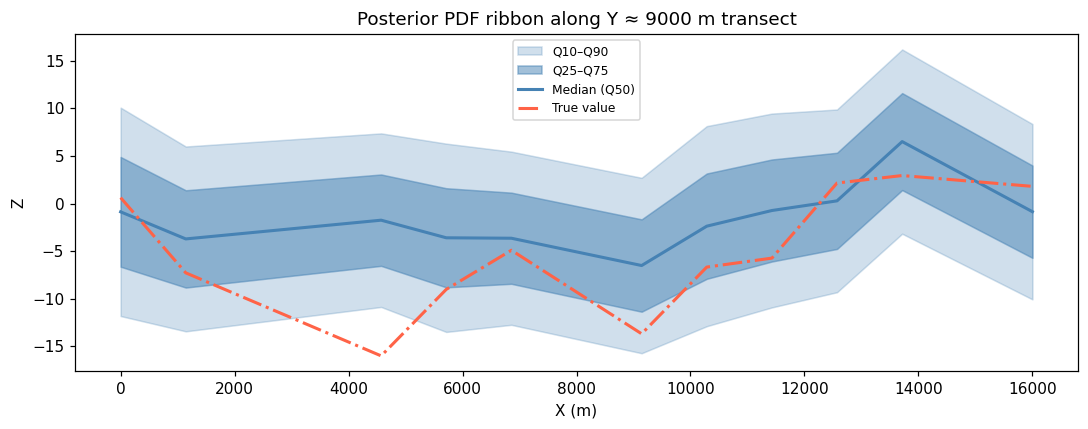

Transect: 11 estimation points at Y ≈ 9000 m


In [17]:
# ── PDF ribbon transect along the centre row of the estimation grid ───────────
# Pick the row of estimation nodes closest to the grid mid-latitude.
y_mid = 0.5 * (y_sim.min() + y_sim.max())
y_est = ck_syn[:, 1]
tol = 0.5 * np.min(np.diff(np.unique(y_est)))
transect_mask = np.abs(y_est - y_mid) < tol

if transect_mask.sum() < 3:
    tol = 1.5 * np.min(np.diff(np.unique(y_est)))
    transect_mask = np.abs(y_est - y_mid) < tol

sort_idx     = np.argsort(ck_syn[transect_mask, 0])
transect_x   = ck_syn[transect_mask, 0][sort_idx]
transect_z   = [z_out_grid[i] for i in np.where(transect_mask)[0][sort_idx]]
transect_pdf = [pdf_out_grid[i] for i in np.where(transect_mask)[0][sort_idx]]
transect_true = z_true[transect_mask][sort_idx]

fig, ax = plt.subplots(figsize=(10, 4))
plot_pdf_ribbon_transect(
    ax, transect_x, transect_z, transect_pdf,
    quantile_levels=[0.1, 0.25, 0.5, 0.75, 0.9],
    true_values=transect_true,
    xlabel='X (m)', ylabel='Z',
)
ax.set_title(f'Posterior PDF ribbon along Y ≈ {y_mid:.0f} m transect')
plt.tight_layout()
plt.show()

print(f'Transect: {len(transect_x)} estimation points at Y ≈ {y_mid:.0f} m')

## 9. Coverage probability verification

For a calibrated Bayesian model, the fraction of true values falling inside a $p$-credible interval should be approximately $p$ (coverage probability).


In [18]:
print('Coverage probability verification:')
print(f"{'CI level':>12}  {'Expected':>10}  {'Observed':>10}  {'Ratio':>8}")
print('-' * 50)

# zlCI[:, j] / zuCI[:, j]: lower/upper bounds for all nk points at CI level j
for j, alpha_ci in enumerate(PCI):
    lo = zlCI[:, j]
    hi = zuCI[:, j]
    inside = (z_true >= lo) & (z_true <= hi) & ~np.isnan(lo)
    obs_coverage = inside.mean()
    print(f'{int(100*alpha_ci):>11}%  {alpha_ci:>10.2f}  {obs_coverage:>10.2f}  '
          f'{obs_coverage/alpha_ci:>8.2f}')


Coverage probability verification:
    CI level    Expected    Observed     Ratio
--------------------------------------------------
         68%        0.68        0.80      1.18
         90%        0.90        0.93      1.04
         99%        0.99        0.99      1.00


In [19]:
# Save BME results for Tutorial 07
import pickle

bme06_results = {
    'bme_mean':    bme_mean,
    'bme_var':     bme_var,
    'ck_syn':      ck_syn,
    'ch_syn':      ch_syn,
    'zh_syn':      zh_syn,
    'zh_full':     zh_full,
    'grid_coords': grid_coords,
    'idx_est':     idx_est,
    'idx_hard':    idx_hard,
    'idx_soft':    idx_soft,
    'cs_syn':      cs_syn,
    'zs_gauss':    zs_gauss,
    'nx': nx, 'ny': ny,
    'x_sim': x_sim, 'y_sim': y_sim,
}
save_path = os.path.join(DATA_DIR, 'tutorial06_bme.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(bme06_results, f)
print('Saved:', save_path)


Saved: /Users/hdragon689/Documents/MyDoc_iCloud/packages/stamps/stamps_v3/tutorials/data/tutorial06_bme.pkl


## 10. Summary

| Step | stamps_v3 function | Notes |
|---|---|---|
| Unconditional simulation | `simuchol(ch, model, param, ns)` | Generate synthetic truth |
| Gaussian soft data (type-2) | `probaGaussian(zmean, zvar)` | `zvar` = **variance** (not std!) |
| Gaussian soft data (type-10) | list of `(10, mean_i, var_i)` tuples | Analytical fast-path |
| BME moments | `BMEPosteriorMoments(...)` | Mean and variance |
| BME full PDF | `BMEPosteriorPDF(..., z_grid=z_grid)` | Full posterior PDF (auto-range if `z_grid` omitted) |
| BME quantiles | `BMEPosteriorQtl(..., quantiles=[...])` | Quantile values at each estimation location |
| Credible intervals | `BMEPosteriorCI(..., ci_probs)` | Bayesian intervals |
| Exceedance map | `plot_exceedance_map(ax, ck, z_out, pdf_out, threshold)` | P(Z > threshold) colour mesh |
| IQR map | `plot_iqr_map(ax, ck, zq_lo, zq_hi)` | Uncertainty via quantile width |
| PDF ribbon transect | `plot_pdf_ribbon_transect(ax, x, z_out, pdf_out)` | Quantile-band envelope |

**Key insights:**

- **Bug fix**: `probaGaussian(zm, zv)` expects `zv` = **variance** $\sigma^2$, not std $\sigma$.  
  Passing `noise_std` instead of `noise_std**2` creates PDFs that are $\sqrt{2}\times$ too narrow  
  and biases all posterior means towards zero.
- **Domain sizing matters**: when the study domain is too large relative to the covariance range,  
  data become too sparse → BME posterior reverts to the (zero) prior mean.
- **Type-10 = exact**: for Gaussian soft data the analytical fast-path is both faster and  
  free of QMC noise — use it whenever possible.
- Coverage probability verifies that the credible intervals are well-calibrated.

**Next:** Tutorial 07 - BME in the space-time domain.
